# Data Structures & Algorithms
# Group Project 2 - Group 12

## Q1: Build a Table of Contents

In [1]:
# Install all dependencies
!pip install pypdf
from pypdf import PdfReader
import sys
sys.path.append("src/")
import re
import string
import math
import collections
import itertools
import wordcloud
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/amberteetsel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Implementation

In [2]:
def importText(book):
    reader = PdfReader(book)
    page = reader.pages
    content = ['n', 'n']
    for chapter in range(1, 3):
        page = reader.pages[chapter]
        content[chapter-1] = page.extract_text().split('\n')

    full_text = [item for sublist in content for item in sublist]

    stripped = []
    
    for item in full_text:
        newItem = item.replace(' .', '')
        stripped.append(newItem)

    stripped.remove('Contents')
    stripped.remove('2')
    stripped.remove('3')

    basket = []
    
    for element in stripped:
        firstSplit = element.split(' ', 1)
        lastSplit = firstSplit[1].rsplit(' ', 1)
        combine = [firstSplit[0], lastSplit[0], lastSplit[-1]]
        basket.append(combine)
    
    return basket

In [3]:
class Node:
    def __init__(self, title):
        self.children = []
        self.title = title

    def addChild(self, title):
        self.children.append(Node(title))
        return self
    
    def __repr__(self, level=0):
        ret = "\t"*level+repr(self.title)+"\n"
        for child in self.children:
            ret += child.__repr__(level+1)
        return ret

In [4]:
def insertTOC(bookName, contents):
    tree = Node(bookName)
    for chapter in contents[1:]:
        dot = chapter[0]
        dotCount = dot.count('.')
        if dotCount == 0:
            tree.addChild(chapter[1])
        elif dotCount == 1:
            tree.children[-1].addChild(chapter[1])
        else:
            tree.children[-1].children[-1].addChild(chapter[1])

    return tree

In [5]:
def preorder_traversal(node):
    if node is None:
        return None
    print(node.title)
    
    for child in node.children:
        preorder_traversal(child)


def postorder_traversal(node):
    if node is None:
        return None
    
    for child in node.children:
        postorder_traversal(child)
    print(node.title)


def level_order_traversal(node):
    if node is None:
        return None
    
    queue = [node]
    
    while len(queue) > 0:
        current = queue[0]
        print(current.title)
        
        new_queue = []
        
        for i in range(1, len(queue)):
            new_queue.append(queue[i])
        queue = new_queue
        
        for child in current.children:
            queue.append(child)


In [6]:
def insert(root, path, title):
   
    current = root
    
    for i in range(len(path)):
        
        idx = path[i] - 1 

        
        
        while len(current.children) <= idx:
            current.children.append(Node(f"Placeholder {len(current.children) + 1}"))

        current = current.children[idx]

    current.addChild(title)


In [7]:
def print_toc(node, mode="plain", level=0, prefix=""):
    
    if node is None:
        return

    if mode == "plain":
        print(node.title)

    elif mode == "indented":
        print("    " * level + node.title)

    elif mode == "numbered":
        current_num = prefix + str(level) if level > 0 else ""
        
        if current_num != "":
            print(current_num + " " + node.title)
        
        else:
            print(node.title)

    for i, child in enumerate(node.children):
        if mode == "numbered":
            new_prefix = prefix + str(i + 1) + "."
            print_toc(child, mode, level + 1, new_prefix)
        
        
        else:
            print_toc(child, mode, level + 1)

In [8]:
def depth(root, title, current_depth=0):
    if root.title == title:
        return current_depth

    for child in root.children:
        d = depth(child, title, current_depth + 1)
        
        if d != -1:
            return d
    return -1

In [9]:
def height(node):
    if node is None:
        return 0
    if len(node.children) == 0:
        return 1
    max_height = 0
    
    
    for child in node.children:
        h = height(child)
        if h > max_height:
            max_height = h
    return max_height + 1

### Testing Suite

In [10]:
# --- TEST CASES ---
# --- Basic Use Case on Hard Coded Data ---

book = Node("Data Science Book")

# Inserting chapters and subchapters
book.addChild("Chapter 1: Introduction")
book.children[0].addChild("1.1 What is Data Science?")
book.children[0].addChild("1.2 History of Data Science")

book.addChild("Chapter 2: Statistics")
book.children[1].addChild("2.1 Probability Basics")
book.children[1].addChild("2.2 Distributions")

# Test traversal
print("\nPreorder Traversal:")
preorder_traversal(book)

print("\nPostorder Traversal:")
postorder_traversal(book)

print("\nLevel Order Traversal:")
level_order_traversal(book)

# Test print_toc modes
print("\nPlain TOC:")
print_toc(book, "plain")

print("\nIndented TOC:")
print_toc(book, "indented")

print("\nNumbered TOC:")
print_toc(book, "numbered")

# Test depth and height
print("\nDepth of '2.1 Probability Basics':", depth(book, "2.1 Probability Basics"))
print("Height of the tree:", height(book))


Preorder Traversal:
Data Science Book
Chapter 1: Introduction
1.1 What is Data Science?
1.2 History of Data Science
Chapter 2: Statistics
2.1 Probability Basics
2.2 Distributions

Postorder Traversal:
1.1 What is Data Science?
1.2 History of Data Science
Chapter 1: Introduction
2.1 Probability Basics
2.2 Distributions
Chapter 2: Statistics
Data Science Book

Level Order Traversal:
Data Science Book
Chapter 1: Introduction
Chapter 2: Statistics
1.1 What is Data Science?
1.2 History of Data Science
2.1 Probability Basics
2.2 Distributions

Plain TOC:
Data Science Book
Chapter 1: Introduction
1.1 What is Data Science?
1.2 History of Data Science
Chapter 2: Statistics
2.1 Probability Basics
2.2 Distributions

Indented TOC:
Data Science Book
    Chapter 1: Introduction
        1.1 What is Data Science?
        1.2 History of Data Science
    Chapter 2: Statistics
        2.1 Probability Basics
        2.2 Distributions

Numbered TOC:
Data Science Book
1.1 Chapter 1: Introduction
1.1.2 1.1 

In [11]:
# --- TEST CASES ---
# --- Use Case with Data from the Book! --
contents = importText('Foundations_of_Data_ScienceTOC.pdf')
book2 = insertTOC('Foundations of Data Science', contents)

# Test traversal
print("\nPreorder Traversal:")
preorder_traversal(book2)

print("\nPostorder Traversal:")
postorder_traversal(book2)

print("\nLevel Order Traversal:")
level_order_traversal(book2)

# Test print_toc modes
print("\nPlain TOC:")
print_toc(book2, "plain")

print("\nIndented TOC:")
print_toc(book2, "indented")

print("\nNumbered TOC:")
print_toc(book2, "numbered")

# Test depth and height
print("\nDepth of 'Volume of the Unit Ball':", depth(book2, "Volume of the Unit Ball"))
print("Height of the tree:", height(book2))


Preorder Traversal:
Foundations of Data Science
High-Dimensional Space
Introduction
The Law of Large Numbers
The Geometry of High Dimensions
Properties of the Unit Ball
Volume of the Unit Ball
Volume Near the Equator
Generating Points Uniformly at Random from a Ball
Gaussians in High Dimension
Random Projection and Johnson-Lindenstrauss Lemma
Separating Gaussians
Fitting a Spherical Gaussian to Data
Bibliographic Notes
Exercises
Best-Fit Subspaces and Singular Value Decomposition (SVD)
Introduction
Preliminaries
Singular Vectors
Singular Value Decomposition (SVD)
Best Rank- k Approximations
Left Singular Vectors
Power Method for Singular Value Decomposition
A Faster Method
Singular Vectors and Eigenvectors
Applications of Singular Value Decomposition
Centering Data
Principal Component Analysis
Clustering a Mixture of Spherical Gaussians
Ranking Documents and Web Pages
An Application of SVD to a Discrete Optimization Problem
Bibliographic Notes
Exercises
Random Walks and Markov Chains


### Time Complexity:

**importText - O(n) -** Because this Reads and processes each line from the PDF once.

**addchild - O(1) -** it just adds the child nodes in constant time when called.

**insertTOC - O(n) -** it iterates from first till the last Table of contents.

**insert - O(d) -** because it will first traverse till the depth.

**preorder, postorder, levelorder traversal functions - O(n) -** it visits each node once

**depth - worst case O(n) -** may need to traverse all nodes
        **best case O(1) -** if the target is near root

**height - O(n) -** visits all nodes in each subtree to find the max height



-----------------------
## Q2: Letters and Words

## Analysis of *Little Women* by Louisa May Alcott

### Preprocessing

In [12]:
from LettersAndWords import process_book, tokenize, remove_stopwords

In [13]:
# Define file names
input_txt = "TextFiles/Little_Women_Full.txt"
output = "TextFiles/Little_Women.txt"

# Markers for start/end of actual novel
start = "*** START OF THE PROJECT GUTENBERG EBOOK LITTLE WOMEN ***"
end = "*** END OF THE PROJECT GUTENBERG EBOOK LITTLE WOMEN ***"

clean_text = process_book(input_txt, output, start, end)

tokens = tokenize(clean_text)

lw = remove_stopwords(tokens)[0]

#### Summary of Preprocessing Effects

In [14]:
# Tokens before stopword removal
n_tokens = len(tokens)
print(f"Original Token Count: {n_tokens:,}")
# Tokens after stopword removal
n_lw = len(lw)
print(f"Post-Processing Token Count: {n_lw:,}")
print(f"Percent of Tokens Removed: {(n_tokens-n_lw)/n_tokens:.2%}")

Original Token Count: 186,088
Post-Processing Token Count: 90,565
Percent of Tokens Removed: 51.33%


### Outputs

#### Letter Frequencies

Alphabetical                   By Frequency                  
         Letter  Count Proportion       Letter  Count Proportion
0             a  62921   0.081257            e  95978   0.123947
1             b  12158   0.015701            t  66827   0.086301
2             c  15837   0.020452            a  62921   0.081257
3             d  37501   0.048429            o  59526   0.076872
4             e  95978   0.123947            n  51465   0.066462
5             f  17291   0.022330            i  50701   0.065476
6             g  17395   0.022464            h  48428   0.062540
7             h  48428   0.062540            s  47166   0.060911
8             i  50701   0.065476            r  45232   0.058413
9             j   2288   0.002955            d  37501   0.048429
10            k   7577   0.009785            l  34862   0.045021
11            l  34862   0.045021            u  22758   0.029390
12            m  19825   0.025602            m  19825   0.025602
13            n  51465   0.066462            w  18515   0.023910
14            o  59526   0.076872            y  18040   0.023297
15            p  13073   0.016883            g  17395   0.022464
16            q    772   0.000997            f  17291   0.022330
17            r  45232   0.058413            c  15837   0.020452
18            s  47166   0.060911            p  13073   0.016883
19            t  66827   0.086301            b  12158   0.015701
20            u  22758   0.029390            k   7577   0.009785
21            v   7041   0.009093            v   7041   0.009093
22            w  18515   0.023910            j   2288   0.002955
23            x    881   0.001138            x    881   0.001138
24            y  18040   0.023297            q    772   0.000997
25            z    290   0.000375            z    290   0.000375

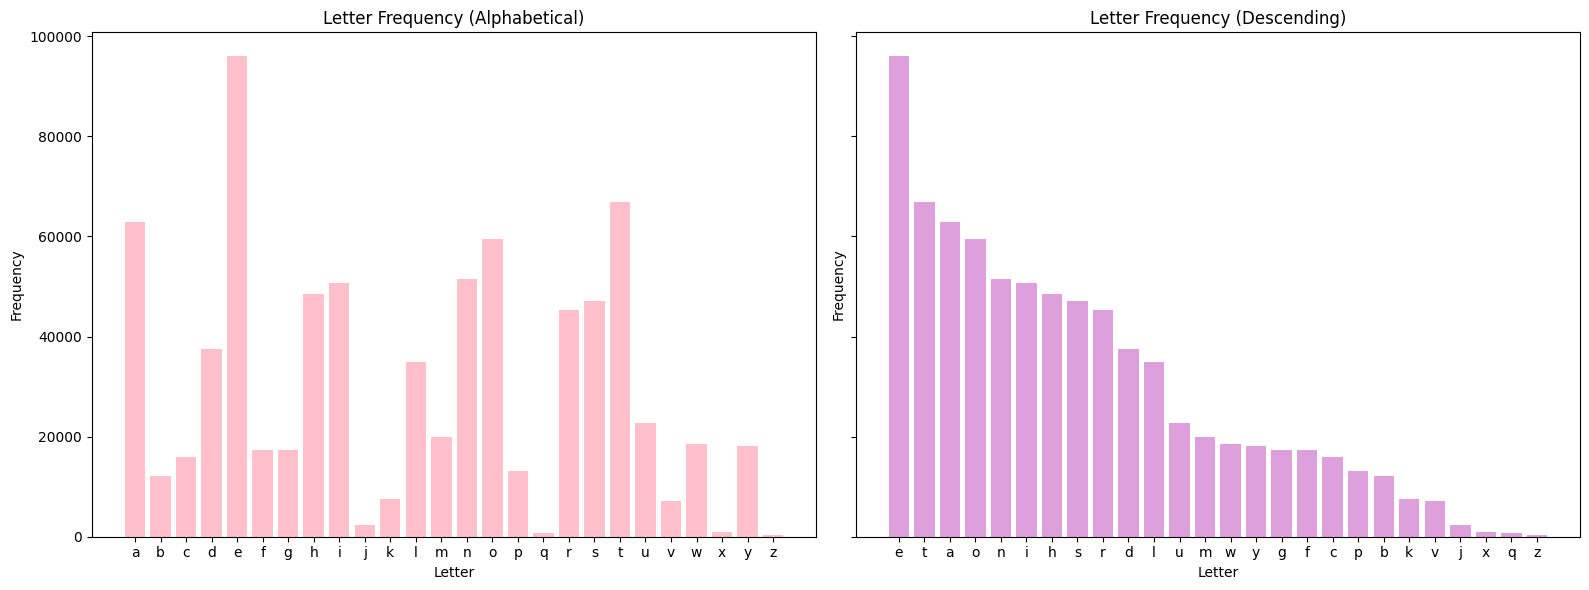

<Figure size 640x480 with 0 Axes>

In [15]:
# Get counts
counts = collections.Counter(clean_text)
# Remove whitespace entry
counts.pop(' ', None)
# All letters a-z
az = list(string.ascii_lowercase)
freq = [counts.get(ltr,0) for ltr in az]

# DataFrames
df = pd.DataFrame({'Letter': az, 'Count': freq})
df['Proportion'] = df['Count']/df['Count'].sum()
df_sorted = df.sort_values(by='Count', ascending=False).reset_index(drop=True)
dfs = pd.concat([df, df_sorted], axis=1, keys=['Alphabetical', 'By Frequency'])
display(dfs)

# Bar Charts
## 2 subplots, 1 row & 2 cols
fig, ax = plt.subplots(1, 2, figsize = (16,6), sharey = True)

## Alphabetical
ax[0].bar(df.Letter, df.Count, color='pink')
ax[0].set_title('Letter Frequency (Alphabetical)')
ax[0].set_xlabel('Letter')
ax[0].set_ylabel('Frequency')

## By Frequency
ax[1].bar(df_sorted.Letter, df_sorted.Count, color='plum')
ax[1].set_title('Letter Frequency (Descending)')
ax[1].set_xlabel('Letter')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
plt.savefig('Images/letter_count_bar.png')

#### Word Frequencies (after stopword removal)

##### Using Default Stopwords Only

,Word,Frequency
0,jo,1247
1,said,826
2,little,725
3,one,702
4,meg,633
5,like,583
6,amy,571
7,laurie,547
8,would,444
9,good,430


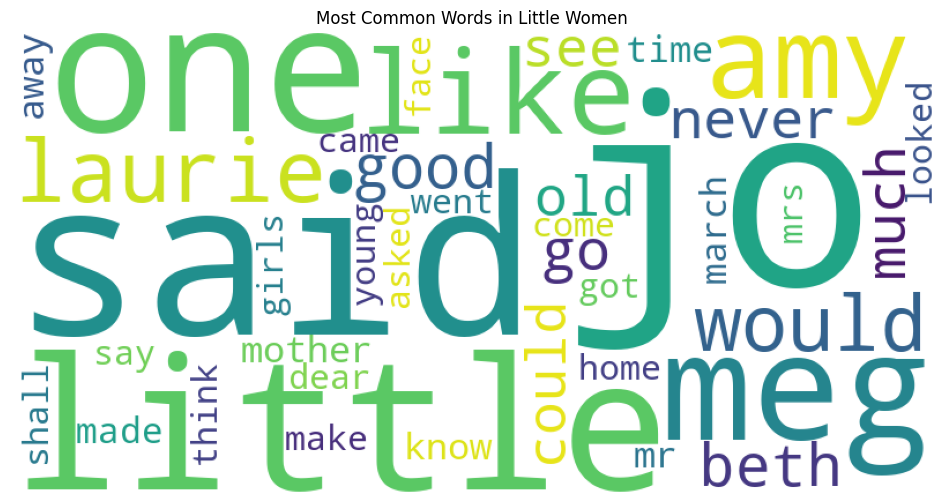

<Figure size 640x480 with 0 Axes>

In [16]:
word_counts = collections.Counter(lw)

top40 = word_counts.most_common(40)

df_words = pd.DataFrame(top40, columns=['Word', 'Frequency'])
display(df_words)

# Word Cloud
wc = wordcloud.WordCloud(width=800, height=400, background_color='white', colormap='viridis')
wc.generate_from_frequencies(dict(top40))
plt.figure(figsize=(14,6))
plt.imshow(wc)
plt.axis('off')
plt.title('Most Common Words in Little Women')
plt.show()
plt.savefig('Images/word_cloud.png')

##### Using Additional Analyst-Defined 'Stopwords'

,Word,Frequency
0,jo,1247
1,little,725
2,meg,633
3,amy,571
4,laurie,547
5,good,430
6,beth,414
7,go,390
8,never,375
9,old,362


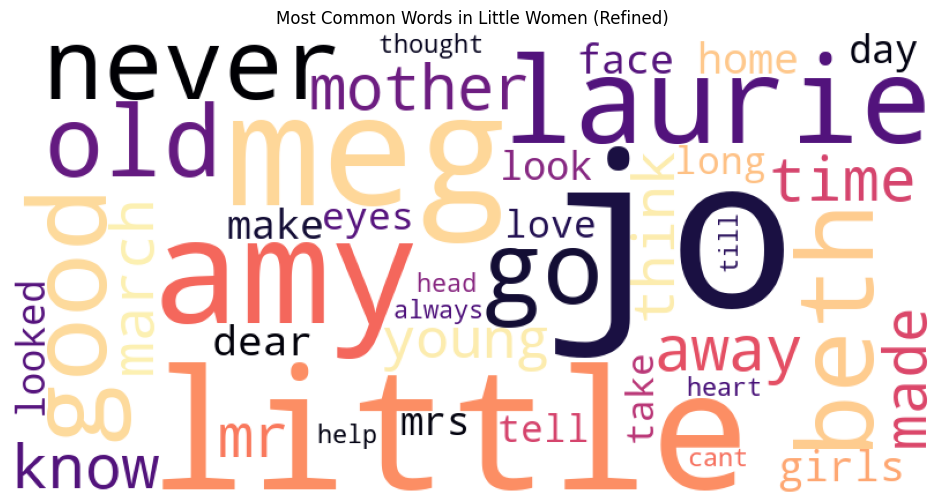

In [17]:
# Further refine words included in analysis
xtra_stops = ["said", "one", "like", "would", "much", "could",
              "see", "say", "come", "came", "went", "got",
              "asked", "shall", "get", "things", "way", "put"]

lw2 = [word for word in lw if word not in xtra_stops]
word_counts = collections.Counter(lw2)

top40 = word_counts.most_common(40)
top40

df_words = pd.DataFrame(top40, columns=['Word', 'Frequency'])
display(df_words)

# Word Cloud
wc = wordcloud.WordCloud(width=800, height=400, background_color='white', colormap='magma_r')
wc.generate_from_frequencies(dict(top40))
plt.figure(figsize=(14,6))
plt.title('Most Common Words in Little Women (Refined)')
plt.imshow(wc)
plt.axis('off')
plt.show()

#### Bigrams & Trigrams

In [18]:
# Tokenize clean version of text so we have each word individually, though this will include stopwords
book = tokenize(clean_text)

clean_stop_words = remove_stopwords(tokens)[1]

# Use itertools to offset list of words by 1 (for bigrams) or 2 (for trigrams) and zip consecutive words together
bigrams = list(zip(book, book[1:]))
trigrams = list(zip(book, book[1:], book[2:]))

# Filter out entries containing stopwords (avoids things like "to the", "i am", etc.)
bigrams_clean = [bg for bg in bigrams if sum(1 for w in bg if w in clean_stop_words) == 0]
trigrams_clean = [tg for tg in trigrams if sum(1 for w in tg if w in clean_stop_words) < 1]

# Get frequencies
bicounts = collections.Counter(bigrams_clean)
tricounts = collections.Counter(trigrams_clean)

# Top 20
bi20 = bicounts.most_common(20)
tri20 = tricounts.most_common(20)

# df's
df_bi = pd.DataFrame(bi20, columns=['Bigram', 'Frequency'])
df_tri = pd.DataFrame(tri20, columns=['Trigram', 'Frequency'])

df_bitri = pd.concat([df_bi, df_tri], axis=1, keys=['Bigrams', 'Trigrams'])

display(df_bitri)

Bigrams                           Trigrams          
              Bigram Frequency                  Trigram Frequency
0       (mrs, march)       142       (said, mrs, march)        25
1         (said, jo)       118     (said, meg, looking)         7
2      (aunt, march)        76       (said, mr, brooke)         7
3        (said, meg)        75       (mrs, march, said)         6
4     (mr, laurence)        67      (old, mr, laurence)         6
5       (mr, brooke)        59    (said, jo, decidedly)         6
6        (mr, bhaer)        57      (asked, mrs, march)         6
7        (said, amy)        56      (said, jo, looking)         5
8        (cried, jo)        51     (mrs, march, looked)         5
9   (old, gentleman)        50      (bad, effect, upon)         5
10    (said, laurie)        47     (mr, brooke, looked)         5
11       (old, lady)        37     (love, one, another)         5
12    (one, another)        36  (falling, summer, rain)         5
13     (young, lady)        34    (replied, mrs, march)         4
14       (asked, jo)        34      (cried, jo, taking)         4
15      (every, day)        31     (mrs, march, smiled)         4
16      (said, beth)        30  (said, laurie, looking)         4
17   (young, ladies)        30       (door, flew, open)         4
18       (said, mrs)        28     (said, mr, laurence)         4
19       (mr, march)        26        (new, years, eve)         3

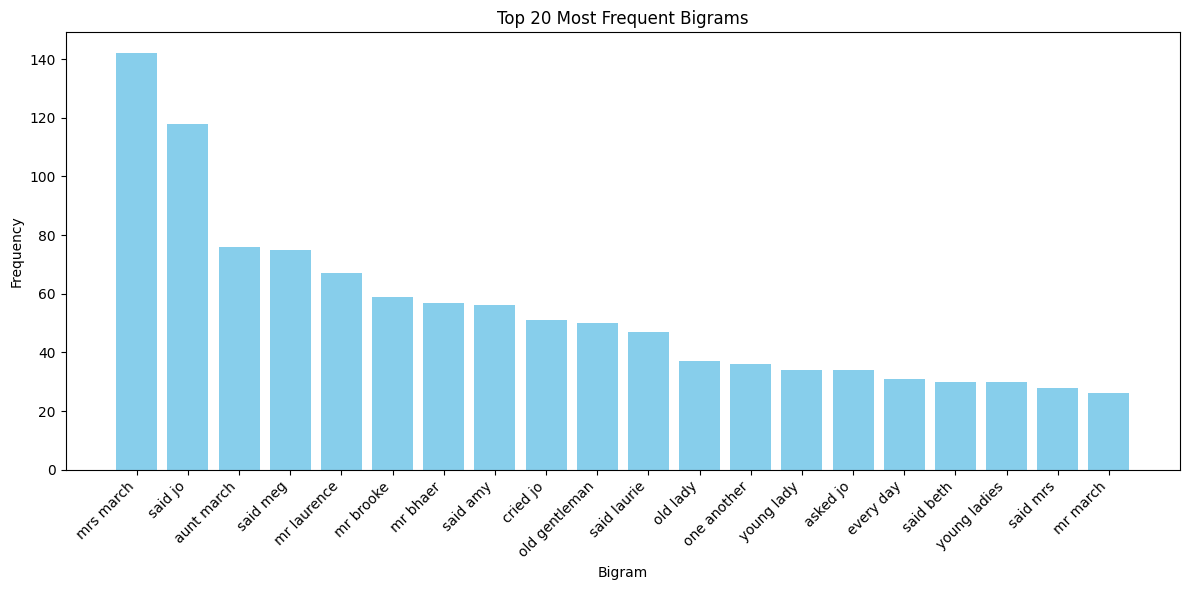

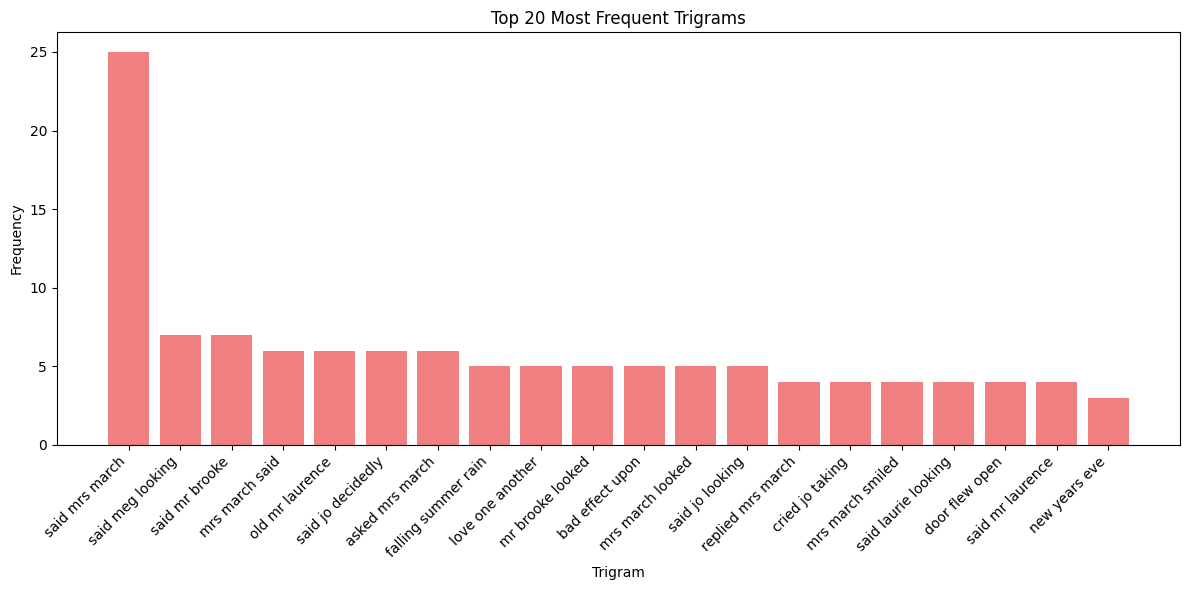

In [19]:
# Plots - bar charts of frequency of 20 most common bigrams/trigrams
# concat bigrams into one string
df_bi['Label'] = df_bi['Bigram'].apply(lambda x: ' '.join(x))

plt.figure(figsize=(12, 6))
# sort by frequency in descending order for plotting
df_bi = df_bi.sort_values(by='Frequency', ascending=False)
plt.bar(df_bi['Label'], df_bi['Frequency'], color='skyblue')
plt.xlabel('Bigram')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Bigrams')
# Rotate x-axis labels for readability, aligning to the right (ha='right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.savefig('Images/bigrams_bar_chart.png')
plt.close()

# --- Trigrams Bar Chart ---

df_tri['Label'] = df_tri['Trigram'].apply(lambda x: ' '.join(x))

plt.figure(figsize=(12, 6))

df_tri = df_tri.sort_values(by='Frequency', ascending=False)
plt.bar(df_tri['Label'], df_tri['Frequency'], color='lightcoral')
plt.xlabel('Trigram')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Trigrams')
# Rotate x-axis labels for readability, aligning to the right (ha='right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.savefig('Images/trigrams_bar_chart.png')
plt.close()

### Discussion

#### Big-O Complexity of Preprocessing

Let $L$ be the total number of characters in the text, and let $N$ be the total number of words/items in a list:

- Reading Text File

    - Time Complexity $O(L)$
    - Space Complexity $O(L)$: Must store entire text in memory   <br><br>

- Extract Main Text

    - Time Complexity $O(L)$: Scan through full text to find specific substrings
    - Space Complexity $O(L)$   <br><br>
 
- Convert to Lowercase

    - Time Complexity $O(L)$: Creating the lowercase version is proportional to the string length   <br><br>
 
- Regex Cleaning

    - Time Complexity $O(L)$: Regular expression substitution is typically linear with respect to the input string length
    - Space Complexity $O(L)$: Must store the characters to reconstruct   <br><br>

- Whitespace Cleanup

    - Time Complexity $O(L)$: Splitting the string into tokens is proportional to the string length
    - Let $N$ be the number of tokens/words, then $N \le L$   <br><br>
 
- Tokenization

    - Time Complexity $O(L)$: Scan each character once to find whitespaces to split
    - Space Complexity $O(N)$: Store a list of words   <br><br>

- Stopword Cleanup

    - Time Complexity $O(N)$ or $O(1)$: Proportional to the number of stopwords
    - The `nltk` library's english stopwords list contains $\approx 200$ words so we can assume constant time in this case, or $O(1)$   <br><br>

- Stopword Filtering

    - Time Complexity $O(N)$: Iterating through $N$ tokens and performing lookups in the set (clean_stop_words)   <br><br>

##### Since $N \le L$ (the number of words is less than or equal to the number of characters) and all major sequential processing steps are $O(L)$ or $O(N)$, the overall time complexity of the code is $O(L)$, making it very efficient for processing large text files. Space Complexity is also $O(L)$ because any temporary data is proportional to the size of the text.

#### Big O Complexity of Counting

Let $N$ be the number of total words in our final tokenized list or the number of total characters in a text file, depending on the scenario.

The time complexity of the provided code is dominated by the initial counting and sorting steps.The overall time complexity is $O(N)$, where $N$ is the total number of words in the input list lw.The complexity is linear because the most intensive operations depend directly on the size of the input list of words ($N$), while the subsequent steps operate on a fixed, small number of items (40).

`collections.Counter(list_of_words_or_text)` has time complexity of $O(N)$ because it needs to check every word, and space complexity of $O(\leq N)$ because it only stores the unique words

`most_common(40)` has time complexity of $O(N)$ and space complexity of $O(1)$ because 40 is a constant.

At this stage we're working with a small list of 40 words/letters and all operations have complexity of either $O(N)$ or $O(1)$

Overall Time & Space Complexity: $O(N)$

#### Interpretation of Text Distributions:

1) Letter Frequency

   'e' is the most frequently occurring letter, consistent with the Cornell Department of Mathematic's English Letter Frequency Table.

   Cornell's data shows that 'v', 'k', 'x', 'q', 'j', and 'z' are the least common letters in the English language. *Little Women* largely follows this pattern but diverges on the letter 'j'. Cornell's data has 'j' occurring at $0.1 \%$ overall. In contrast, this analysis finds that 'j' occurs at $\approx 0.3\%$ in *Little Women*, three times more frequently than in the English language as a whole. This can be explained by the fact that the main character's name is Jo and that is the most frequently used word in the novel (see below).

3) Word Frequency (after additional stopword removal)

   The most frequent word in *Little Women* is "Jo", the name of our protagonist, with 1,247 references. Appropriately, the top 10 most frequent words also include "Meg" (633), "Amy" (571), "Laurie" (547), "Beth" (414), and "Mother" (328); these are the names of the other main characters (excluding Mr. March/Father, to be discussed below). Jo's prescence in the text is double or more than that of her other sisters. "Beth" is referenced the least among the March Sisters - the character passes away in the middle of the novel, but her preceding illness is oft talked about among the family and neighbors. However, Beth has the least conflict with her sisters which could explain why her name is the least-frequently referenced among the four.

   The second most frequent word is aptly part of the novel's title, "little" with 725 instances. "Women", however, only appears 44 times. The name "Laurie" is the 4th-most common word, which is also expected given he is Jo's best friend and love interest.

   
5) Bigram analysis

   Among the top 40 bigrams, 'mrs march' has the highest frequency of occurrence (142) and 'mr march' has lowest frequency of occurrence (26). This makes sense as these characters are among the only referenced by their full title/name. Mr. March is absent for most of the book, explaining why he has fewer references than Mrs. March.

    The bigrams "young lady" and "young ladies" are also in the top 20 most frequent with a combined 64 references - note that these phrases are essentially synonyms for the novel's title.

7) Trigram Analysis

   Trigram '(said, mrs, march)' has highest frequency of occurrence (25). As discussed in Part 4, Mrs. March is one of the only characters referred to by two separate words instead of just a first or last name. Therefore it makes sense that her dialogue (or any other reference to her) would come up more often in trigrams.

   Trigram '(new, years, eve)' has lowest frequency of occurrence within the top 20 (3).

Reference: [Cornell Department of Mathematic's English Letter Frequency Table](https://pi.math.cornell.edu/~mec/2003-2004/cryptography/subs/frequencies.html)

### Testing Suite

##### Verify process_book works if appropriate start/end markers are inputted

In [20]:
# Define file names
input_txt = "TextFiles/Test_Book_AliceInWonderland.txt"
output = "TextFiles/Test_AliceInWonderland.txt"

# Markers for start/end of actual novel
start = "*** START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND ***"
end = "*** END OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND ***"

clean_alice = process_book(input_txt, output, start, end)
print(clean_alice[:1000])
print(type(output))

illustration alices adventures in wonderland by lewis carroll the millennium fulcrum edition contents chapter i down the rabbithole chapter ii the pool of tears chapter iii a caucusrace and a long tale chapter iv the rabbit sends in a little bill chapter v advice from a caterpillar chapter vi pig and pepper chapter vii a mad teaparty chapter viii the queens croquetground chapter ix the mock turtles story chapter x the lobster quadrille chapter xi who stole the tarts chapter xii alices evidence chapter i down the rabbithole alice was beginning to get very tired of sitting by her sister on the bank and of having nothing to do once or twice she had peeped into the book her sister was reading but it had no pictures or conversations in it and what is the use of a book thought alice without pictures or conversations so she was considering in her own mind as well as she could for the hot day made her feel very sleepy and stupid whether the pleasure of making a daisychain would be worth the tr

##### Test tokenize() on *Alice in Wonderland*

In [21]:
alice_tokens = tokenize(clean_alice)
print(alice_tokens[100:125])

['on', 'the', 'bank', 'and', 'of', 'having', 'nothing', 'to', 'do', 'once', 'or', 'twice', 'she', 'had', 'peeped', 'into', 'the', 'book', 'her', 'sister', 'was', 'reading', 'but', 'it', 'had']


##### Test remove_stopwords() on *Alice in Wonderland*

In [22]:
alice_final = remove_stopwords(alice_tokens)[0]

# Tokens before stopword removal
n_tokens = len(alice_tokens)
print(f"Original Token Count: {n_tokens:,}")
# Tokens after stopword removal
n_alice_final = len(alice_final)
print(f"Post-Processing Token Count: {n_alice_final:,}")
print(f"Percent of Tokens Removed: {(n_tokens-n_alice_final)/n_tokens:.2%}")
print(alice_final[100:125])

Original Token Count: 26,464
Post-Processing Token Count: 12,180
Percent of Tokens Removed: 53.98%
['think', 'much', 'way', 'hear', 'rabbit', 'say', 'oh', 'dear', 'oh', 'dear', 'shall', 'late', 'thought', 'afterwards', 'occurred', 'ought', 'wondered', 'time', 'seemed', 'quite', 'natural', 'rabbit', 'actually', 'took', 'watch']


##### Verify that function process_book returns ValueError if the specified start/end markers are not found

In [23]:
# Define file names
input_txt = "TextFiles/Test_Book_AliceInWonderland.txt"
output = "TextFiles/Test_AliceInWonderland.txt"

# Markers for start/end of actual novel
start = "*** START OF THE PROJECT GUTENBERG EBOOK LITTLE WOMEN ***"
end = "*** END OF THE PROJECT GUTENBERG EBOOK LITTLE WOMEN ***"

# Test
try:
    clean_alice = process_book(input_txt, output, start, end)
    clean_alice[:1000]
except ValueError:
    print(f"ValueError raised appropriately; function working as expected")

ValueError raised appropriately; function working as expected
